In [23]:
import numpy as np
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [39]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [21]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [24]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text =text.lower()
  print('lower case',text)

  text = re.sub(r'[^a-za-z\s]','', text)
  print('special character',text)

  text = word_tokenize(text)
  print('tokenization',text)

  text = [word for word in text if word not in stop_words]
  print('stop words',text)

  cleaned_text =" ".join(words)

  return cleaned_text

  df['cleaned_review'] = df['Review'].apply(clean_text)

  print('cleaned_review')
  print(df[['Review','cleaned_review']])

In [30]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
  text=text.lower()
  print('lower case',text)

  text = re.sub(r'[^a-zA-Z\s]','',text)
  print('special character',text)

  words = word_tokenize(text)
  print('tokenization',words)

  #Remove stopwords
  words = [word for word in words if word not in stop_words]
  print('stop words',words)

  # join words again
  cleaned_text = " ".join(words)

  return cleaned_text

# apply cleaning function
df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("\n Cleaned Reviews")
print(df['Cleaned_Review'])

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stop words ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stop words ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stop words ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delive

In [40]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound_score = score['compound']
  if compound_score >= 0.05:
    return 'Positive'
  elif compound_score <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'

df['sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)
print("\nsentiment analysis Result")
print(df[['Review','sentiment']])


sentiment analysis Result
                                              Review sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [43]:
from collections import Counter

all_words =" ".join(df['Cleaned_Review'])
word_list =  all_words.split()

word_freq = Counter(word_list)

print('\ntop 10 common keywords')
print(word_freq.most_common(10))


top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [52]:
from os.path import join
negitive_reviews = df[df['sentiment'] == 'Negative']

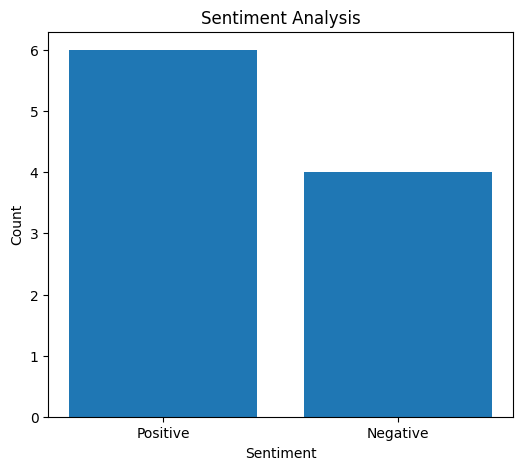

In [47]:
import matplotlib.pyplot as plt
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis')
plt.show()


generate wordcloud
# New Section

Content of negitive_reviews['Cleaned_Review'] before join: ['bad packaging item damaged', 'poor quality product terrible experience', 'product stopped working two days', 'late delivery bad customer support']
Generated all_words string: 'bad packaging item damaged poor quality product terrible experience product stopped working two days late delivery bad customer support'


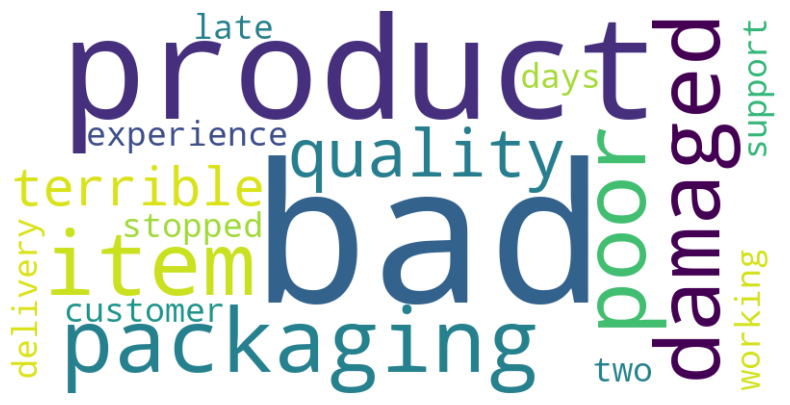

In [53]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Correctly generate the 'all_words' string from negative reviews
print(f"Content of negitive_reviews['Cleaned_Review'] before join: {negitive_reviews['Cleaned_Review'].tolist()}")
all_words = " ".join(negitive_reviews['Cleaned_Review'])
print(f"Generated all_words string: '{all_words}'")

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()